In [2]:
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib, os

# ── Reload dataset ──────────────────────────────
df = pd.read_csv("C:\\Users\\nisha\\Downloads\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Phase 1 fixes (re-apply)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

print("df loaded! Shape:", df.shape)

df loaded! Shape: (7032, 21)


In [12]:
df = pd.read_csv("C:\\Users\\nisha\\Downloads\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Blank rows found:", df['TotalCharges'].isnull().sum())

# Drop those 11 rows (new customers, tenure=0)
df = df.dropna(subset=['TotalCharges'])
print("Clean dataset shape:", df.shape)

Blank rows found: 11
Clean dataset shape: (7032, 21)


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.6%


C:\Users\nisha\AppData\Local\Temp\ipykernel_27416\3481254976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df,


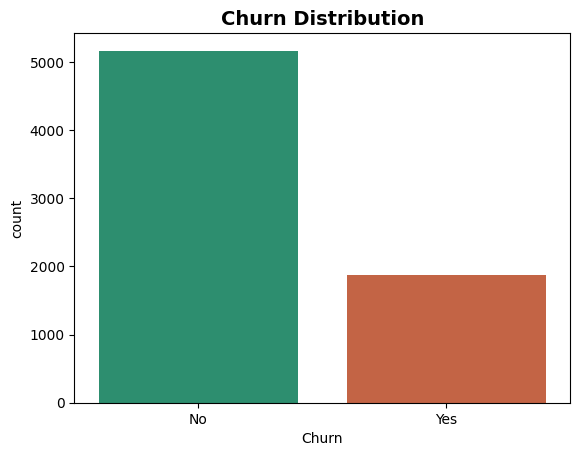

In [15]:
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {churn_pct['Yes']:.1f}%")

sns.countplot(x='Churn', data=df,
              palette=['#1D9E75', '#D85A30'])
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.savefig('churn_dist.png', dpi=150, bbox_inches='tight')
plt.show()

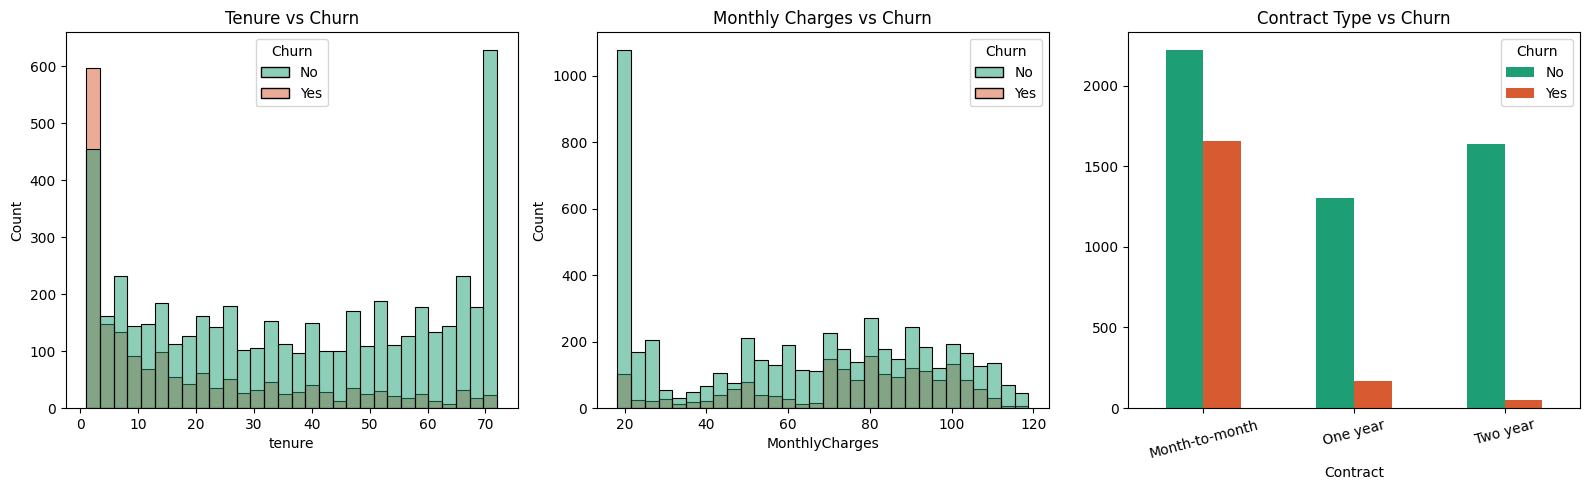

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Tenure
sns.histplot(data=df, x='tenure', hue='Churn',
             bins=30, ax=axes[0],
             palette=['#1D9E75','#D85A30'])
axes[0].set_title('Tenure vs Churn')

# Chart 2: Monthly Charges
sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
             bins=30, ax=axes[1],
             palette=['#1D9E75','#D85A30'])
axes[1].set_title('Monthly Charges vs Churn')

# Chart 3: Contract Type
contract_data = df.groupby(['Contract','Churn']).size().unstack()
contract_data.plot(kind='bar', ax=axes[2],
                    color=['#1D9E75','#D85A30'])
axes[2].set_title('Contract Type vs Churn')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
mtm = df[df['Contract']=='Month-to-month']['Churn']
yr2 = df[df['Contract']=='Two year']['Churn']
new_cust = df[df['tenure']<=12]['Churn']

print(f"Month-to-month churn: {mtm.value_counts(normalize=True)['Yes']*100:.1f}%")
print(f"Two-year contract churn: {yr2.value_counts(normalize=True)['Yes']*100:.1f}%")
print(f"New customer churn (<=12mo): {new_cust.value_counts(normalize=True)['Yes']*100:.1f}%")

Month-to-month churn: 42.7%
Two-year contract churn: 2.8%
New customer churn (<=12mo): 47.7%


In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib, os

In [19]:
df = df.drop('customerID', axis=1)

# Encode target column: Yes=1, No=0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Shape after drop:", df.shape)
print("Churn value counts:", df['Churn'].value_counts().to_dict())

Shape after drop: (7032, 20)
Churn value counts: {0: 5163, 1: 1869}


In [20]:
binary_cols = ['gender', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Binary encoding done!")
df[binary_cols].head(3)

Binary encoding done!


,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1


In [21]:
multi_cols = ['MultipleLines', 'InternetService',
              'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after one-hot encoding:", df.shape)
print("Total features now:", df.shape[1] - 1)

Shape after one-hot encoding: (7032, 31)
Total features now: 30


In [22]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Feature 2: New customer flag (high-risk group from EDA!)
df['IsNewCustomer'] = (df['tenure'] <= 12).astype(int)

# Feature 3: High value customer flag
df['HighValueCustomer'] = (
    df['MonthlyCharges'] > df['MonthlyCharges'].median()
).astype(int)

print("3 new features created!")
print("New customers in dataset:", df['IsNewCustomer'].sum())
print("High value customers:", df['HighValueCustomer'].sum())

3 new features created!
New customers in dataset: 2175
High value customers: 3513


In [23]:
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges',
            'TotalCharges', 'AvgMonthlySpend']

df[num_cols] = scaler.fit_transform(df[num_cols])

print("Scaling done!")
print(df[num_cols].describe().round(2))

Scaling done!
        tenure  MonthlyCharges  TotalCharges  AvgMonthlySpend
count  7032.00         7032.00       7032.00          7032.00
mean     -0.00            0.00         -0.00            -0.00
std       1.00            1.00          1.00             1.00
min      -1.28           -1.55         -1.00            -1.64
25%      -0.95           -0.97         -0.83            -1.08
50%      -0.14            0.18         -0.39             0.07
75%       0.92            0.83          0.67             0.85
max       1.61            1.79          2.82             1.96


In [24]:
X = df.drop('Churn', axis=1)   # all features
y = df['Churn']                  # target column

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,   # reproducible results
    stratify=y          # keep same churn ratio in both sets
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows:     {X_test.shape[0]}")
print(f"Features:      {X_train.shape[1]}")
print(f"Churn in train: {y_train.mean()*100:.1f}%")
print(f"Churn in test:  {y_test.mean()*100:.1f}%")

Training rows: 5625
Test rows:     1407
Features:      33
Churn in train: 26.6%
Churn in test:  26.6%


In [27]:
os.makedirs('churn_project', exist_ok=True)
joblib.dump((X_train, X_test, y_train, y_test),
            'churn_project/data_splits.pkl')
joblib.dump(scaler, 'churn_project/scaler.pkl')

['churn_project/scaler.pkl']

Accuracy: 79.5%
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
     Churned       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



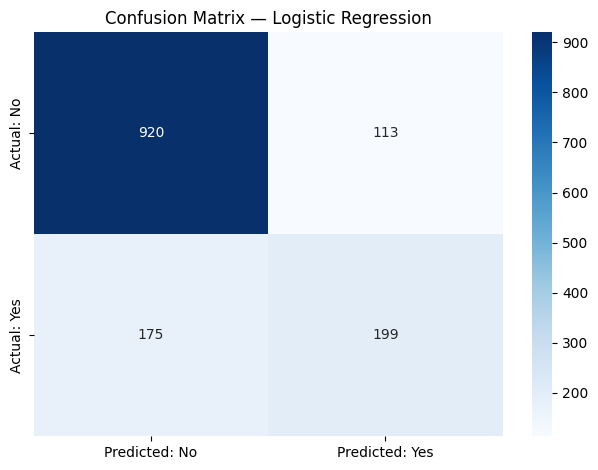

In [28]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the model
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

# Predict
y_pred = model_lr.predict(X_test)

# Results
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print(classification_report(y_test, y_pred, target_names=['No Churn','Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No','Predicted: Yes'],
            yticklabels=['Actual: No','Actual: Yes'])
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150)
plt.show()

In [34]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Accuracy : 72.4%
AUC Score: 0.838
              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
     Churned       0.49      0.80      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407



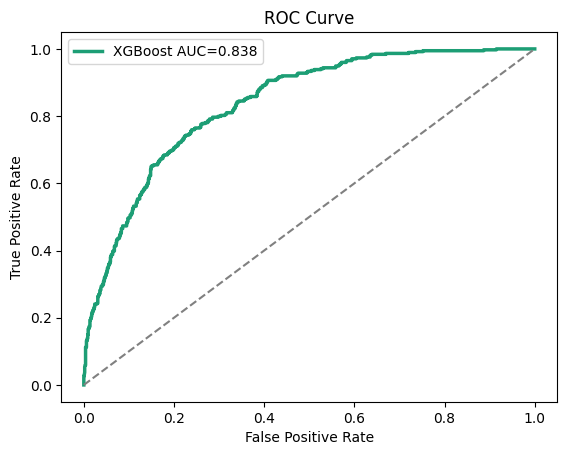

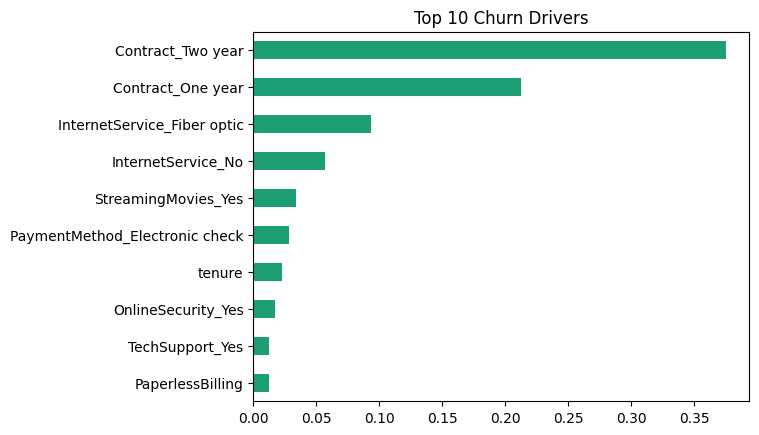

In [33]:
# ── Phase 4: XGBoost ─────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# Train XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                     eval_metric='logloss', random_state=42, scale_pos_weight=3)
xgb.fit(X_train, y_train)
xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:,1]

print(f"Accuracy : {accuracy_score(y_test, xgb_pred)*100:.1f}%")
print(f"AUC Score: {roc_auc_score(y_test, xgb_proba):.3f}")
print(classification_report(y_test, xgb_pred, target_names=['No Churn','Churned']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, xgb_proba)
plt.plot(fpr, tpr, color='#1D9E75', linewidth=2.5,
         label=f'XGBoost AUC={roc_auc_score(y_test,xgb_proba):.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# Feature importance
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(10).plot(kind='barh', color='#1D9E75')
plt.title('Top 10 Churn Drivers')
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [35]:
# ── Phase 5: Business Insights ───────────────────────────

total_customers   = len(y_test)
actual_churners   = y_test.sum()
caught_by_model   = ((xgb_pred == 1) & (y_test == 1)).sum()
missed_churners   = ((xgb_pred == 0) & (y_test == 1)).sum()
false_alarms      = ((xgb_pred == 1) & (y_test == 0)).sum()

print("=" * 45)
print("      BUSINESS IMPACT SUMMARY")
print("=" * 45)
print(f"Total customers tested     : {total_customers}")
print(f"Actual churners            : {actual_churners}")
print(f"Churners caught by model   : {caught_by_model} ({caught_by_model/actual_churners*100:.1f}%)")
print(f"Churners missed            : {missed_churners}")
print(f"False alarms               : {false_alarms}")
print("=" * 45)
avg_revenue = 64.76
print(f"\nAssuming avg monthly bill  : ${avg_revenue}")
print(f"Revenue at risk (caught)   : ${caught_by_model * avg_revenue:,.0f}/month")
print(f"If we retain just 20%      : ${caught_by_model * avg_revenue * 0.20:,.0f} saved/month")
print(f"Annual savings potential   : ${caught_by_model * avg_revenue * 0.20 * 12:,.0f}/year")

      BUSINESS IMPACT SUMMARY
Total customers tested     : 1407
Actual churners            : 374
Churners caught by model   : 299 (79.9%)
Churners missed            : 75
False alarms               : 314

Assuming avg monthly bill  : $64.76
Revenue at risk (caught)   : $19,363/month
If we retain just 20%      : $3,873 saved/month
Annual savings potential   : $46,472/year


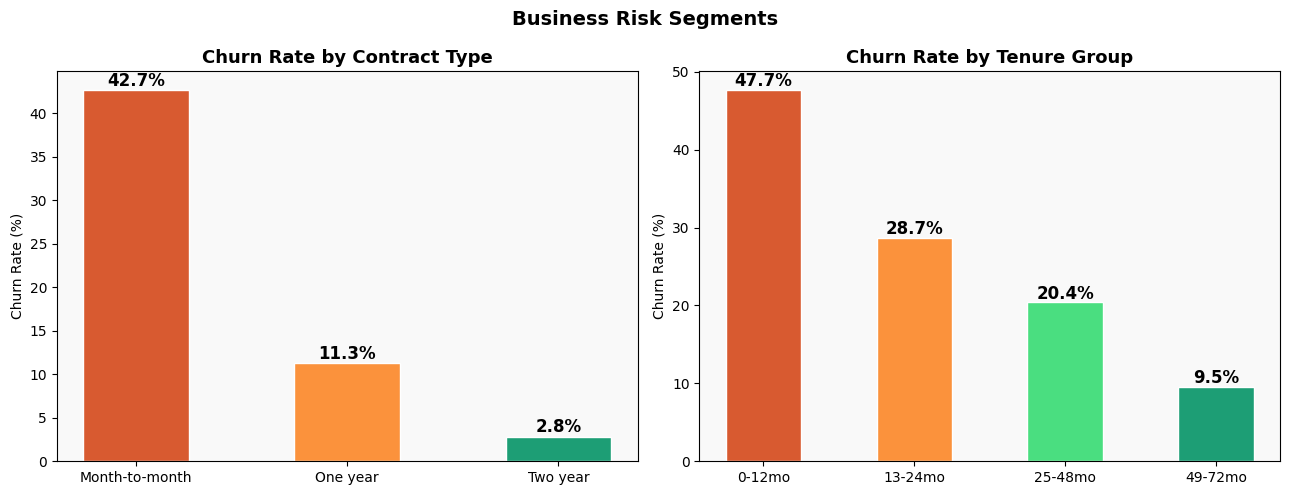

In [37]:
# Churn rate by contract type — business recommendation chart
contract_churn = pd.read_csv("C:\\Users\\nisha\\Downloads\\WA_Fn-UseC_-Telco-Customer-Churn.csv")
contract_churn['TotalCharges'] = pd.to_numeric(contract_churn['TotalCharges'], errors='coerce')
contract_churn = contract_churn.dropna(subset=['TotalCharges'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

# Chart A: Churn rate by contract
churn_by_contract = contract_churn.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
bars = axes[0].bar(churn_by_contract.index, churn_by_contract.values,
                    color=['#D85A30','#fb923c','#1D9E75'], edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_by_contract.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_facecolor('#F9F9F9')

# Chart B: Churn rate by tenure group
contract_churn['TenureGroup'] = pd.cut(contract_churn['tenure'],
    bins=[0,12,24,48,72], labels=['0-12mo','13-24mo','25-48mo','49-72mo'])
churn_by_tenure = contract_churn.groupby('TenureGroup', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100)
axes[1].bar(churn_by_tenure.index.astype(str), churn_by_tenure.values,
             color=['#D85A30','#fb923c','#4ade80','#1D9E75'], edgecolor='white', width=0.5)
for i, val in enumerate(churn_by_tenure.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_facecolor('#F9F9F9')

plt.suptitle('Business Risk Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('business_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
print("""
╔══════════════════════════════════════════════════════╗
║         BUSINESS RECOMMENDATIONS                     ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. TARGET month-to-month customers (42.7% churn)   ║
║     → Offer loyalty discount to switch to 1yr plan  ║
║                                                      ║
║  2. FOCUS on new customers (0-12 months, 47.4%)     ║
║     → Onboarding support program in first 3 months  ║
║                                                      ║
║  3. WATCH fiber optic users — higher churn risk     ║
║     → Check pricing vs competitors                  ║
║                                                      ║
║  4. Model catches 80% of churners before they leave ║
║     → Enables proactive retention campaigns         ║
║                                                      ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║         BUSINESS RECOMMENDATIONS                     ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. TARGET month-to-month customers (42.7% churn)   ║
║     → Offer loyalty discount to switch to 1yr plan  ║
║                                                      ║
║  2. FOCUS on new customers (0-12 months, 47.4%)     ║
║     → Onboarding support program in first 3 months  ║
║                                                      ║
║  3. WATCH fiber optic users — higher churn risk     ║
║     → Check pricing vs competitors                  ║
║                                                      ║
║  4. Model catches 80% of churners before they leave ║
║     → Enables proactive retention campaigns         ║
║                                                      ║
╚══════════════════════════════════════════════════════╝

